In [21]:

import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm
SMALL_SIZE = 13
MEDIUM_SIZE = 15
BIGGER_SIZE = 20

plt.rc('font', size=SMALL_SIZE)          # controls default text sizes
plt.rc('axes', titlesize=SMALL_SIZE)     # fontsize of the axes title
plt.rc('axes', labelsize=MEDIUM_SIZE)    # fontsize of the x and y labels
plt.rc('xtick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
plt.rc('ytick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
plt.rc('legend', fontsize=SMALL_SIZE)    # legend fontsize
plt.rc('figure', titlesize=BIGGER_SIZE)  # fontsize of the figure title

In [2]:
path_start = f"/pfs/10/work/hd_cu284-work/fargo3d/outputs/"
path_endings=["fargo_fiducial_2gen", "fargo_high_mass_2gen",  "fargo_low_mass_2gen", "fargo_high_visc_2gen", "fargo_low_visc_2gen",
              "fargo_sigslop_0_2gen","fargo_sigslop_0.5_2gen", "fargo_sigslop_-2_2gen", "fargo_sigslop_1.5_2gen", "fargo_fiducial_companion" ]

paths = []
for i in range(len(path_endings)):
    paths.append(path_start+path_endings[i])

In [3]:


frames = [0,1,10,100]

rho_cube=[] # first index: which alpha, second index: which snapshot.
for path in paths:
    rho_cube.append([])
    for i in frames:
        rho = np.fromfile(f"{path}/gasdens{i}.dat").reshape(300, 384)
        rho_cube[-1].append(rho)

rho_cube=np.array(rho_cube)

### calculate disk mass at dens=1
au  = 1.49598e13     # Astronomical Unit       [cm]
ms  = 1.98892e33     # Solar mass              [g]
mstar    = 1.08*ms #ms
r0       = 57*au    # The radius corresponding to '1' in dimensionless units

r_min = 0.3
r_max = 7

sigma_0 = 6.3661977237e-4 * mstar / (r0*r0)

rho_cube = rho_cube*mstar/r0**2

/scratch/3208986/ipykernel_3170439/1189089890.py:15: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  plt.pcolormesh(X, Y,np.log10(rho_cube[0][-1]),cmap=cm.Oranges_r)


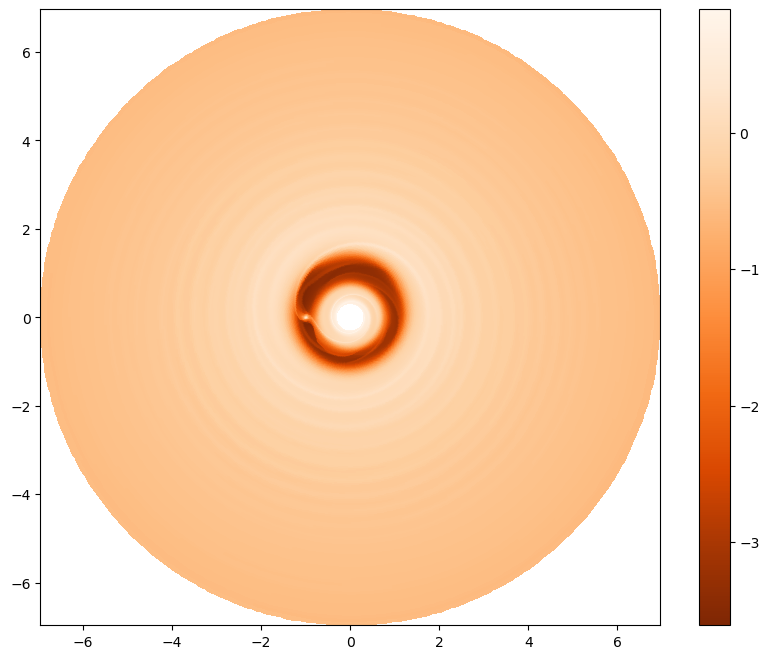

In [4]:
## make this a round plot so I know what's going on.

Nr = 300
Nphi = 384

r_list = np.fromfile(f"{path}/domain_y.dat", sep="\n")[3:-4]
phi = np.linspace(0, 2*np.pi, Nphi)

R, PHI = np.meshgrid(r_list, phi, indexing='ij')

X = R*np.cos(PHI)
Y = R*np.sin(PHI)

plt.figure(figsize=(10,8))
plt.pcolormesh(X, Y,np.log10(rho_cube[0][-1]),cmap=cm.Oranges_r)
plt.colorbar()

# Examining eccentricities for different planet masses

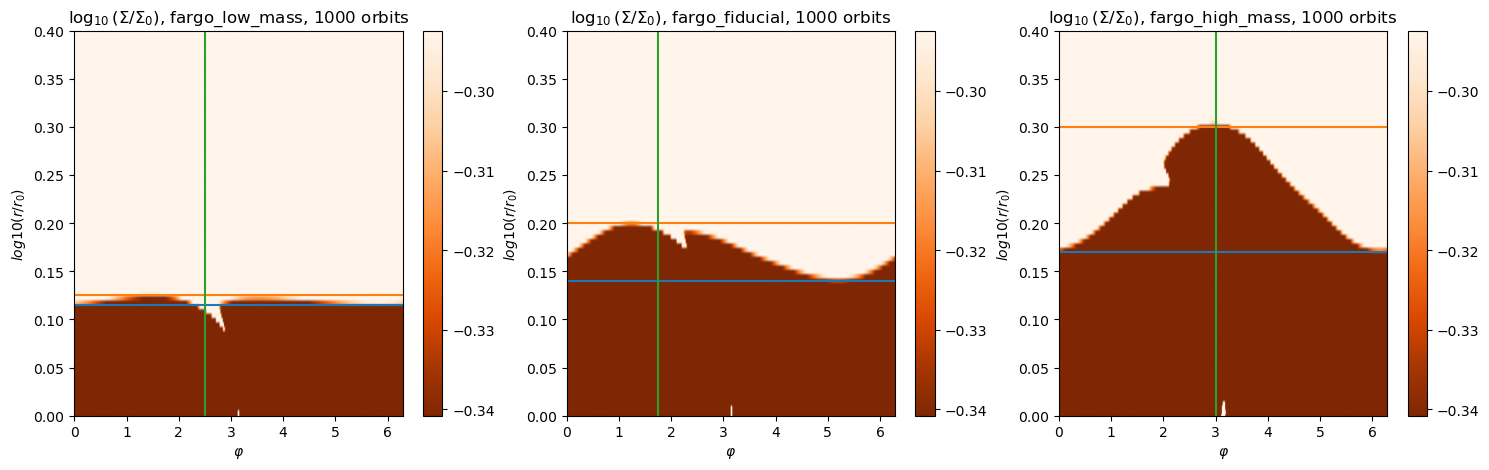

In [5]:
%matplotlib inline
r_min = 0.3
r_max = 7
index_for_mass=[2,0,1]

r_in_log = [0.115,0.14,0.17]
r_out_log = [0.125,0.20,0.30]
phi_ellipse = [2.5,4.9-np.pi,3.0]

plt.figure(figsize=(18,5))
frame = 100

for it,i in enumerate(index_for_mass):
    path = paths[i]
    
        
    plt.subplot(1,3,it+1)
    
    plt.imshow(np.log10(rho_cube[i][-1]/rho_cube[i][0]), origin='lower', cmap=cm.Oranges_r, aspect='auto',extent=[0,2*np.pi,np.log10(r_min), np.log10(r_max)],clim = (np.log10(0.51),np.log10(0.49)))
    plt.plot([0,np.pi*2],[r_in_log[it],r_in_log[it]])
    plt.plot([0,np.pi*2],[r_out_log[it],r_out_log[it]])
    plt.plot([phi_ellipse[it], phi_ellipse[it]],[-0.5,0.8])
    plt.title(f"$\\log_{{10}} \\left(\\Sigma / \\Sigma_0\\right)$, {path[43:-5]}, {(frame)*10} orbits")
    plt.ylim(0,0.4)
    plt.ylabel("$log10(r/r_0)$")
    plt.xlabel("$\\varphi$")
    plt.colorbar()


r_in: 1.4791083881682074
r_out: 1.9952623149688795
Eccentricity for fargo_high_mass: 0.14856040730904885


/scratch/3208986/ipykernel_3170439/3357603413.py:28: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  plt.pcolormesh(X, Y,np.log10(rho_cube[model_ind][-1]/rho_cube[model_ind][0]),cmap=cm.Oranges_r,clim = (np.log10(0.51),np.log10(0.49)))


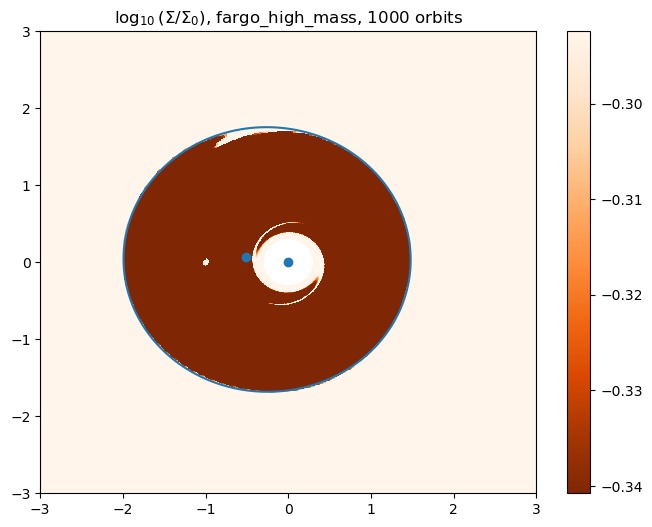

In [6]:
# index_for_mass=[2,0,1]
model_ind = 1

r_in = np.power(10,0.17)
r_out = np.power(10,0.30)

a = (r_in+r_out)/2
e = (r_out-r_in)/2
b = np.sqrt(a**2-e**2)
print(f"r_in: {r_in}\nr_out: {r_out}")
path = paths[model_ind]
print(f"Eccentricity for {path[43:-5]}: {e/a}")

centerx = e
centery = 0
philist = np.linspace(0,2*np.pi,360)

x_ell_ = centerx + a*np.cos(philist)
y_ell_ = centery + b*np.sin(philist)

phi = 3.0
x_ell = x_ell_*np.cos(phi) - y_ell_*np.sin(phi)
y_ell = +x_ell_*np.sin(phi) + y_ell_*np.cos(phi)

plt.figure(figsize=(8,6))
plt.plot(x_ell,y_ell)
plt.scatter([0,2*e*np.cos(phi)],[0,2*e*np.sin(phi)], zorder=3)
plt.pcolormesh(X, Y,np.log10(rho_cube[model_ind][-1]/rho_cube[model_ind][0]),cmap=cm.Oranges_r,clim = (np.log10(0.51),np.log10(0.49)))

plt.title(f"$\\log_{{10}} \\left(\\Sigma / \\Sigma_0\\right)$, {path[43:-5]}, {(frame)*10} orbits")
plt.xlim(-3,3)
plt.ylim(-3,3)
plt.colorbar()

r_in: 1.3803842646028848
r_out: 1.5848931924611136
Eccentricity for fargo_fiducial: 0.06896788945366301
e : 0.10225446392911441


/scratch/3208986/ipykernel_3170439/908882395.py:30: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  plt.pcolormesh(X, Y,np.log10(rho_cube[model_ind][-1]/rho_cube[model_ind][0]),cmap=cm.Oranges_r,clim = (np.log10(0.51),np.log10(0.49)))


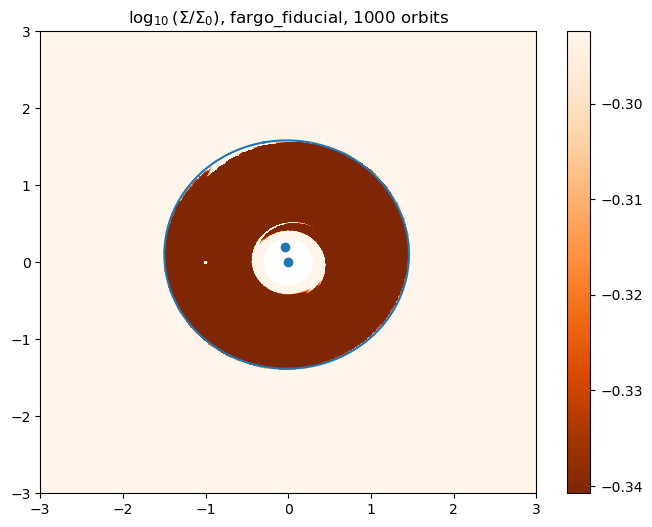

In [7]:
# index_for_mass=[2,0,1]
model_ind = 0

r_in = np.power(10,0.14)
r_out = np.power(10,0.20)
print(f"r_in: {r_in}\nr_out: {r_out}")

a = (r_in+r_out)/2
e = (r_out-r_in)/2
b = np.sqrt(a**2-e**2)

path = paths[model_ind]
print(f"Eccentricity for {path[43:-5]}: {e/a}")
print(f"e : {e}")

centerx = e
centery = 0
philist = np.linspace(0,2*np.pi,360)

x_ell_ = centerx + a*np.cos(philist)
y_ell_ = centery + b*np.sin(philist)

phi = 4.9 - np.pi
x_ell = x_ell_*np.cos(phi) - y_ell_*np.sin(phi)
y_ell = +x_ell_*np.sin(phi) + y_ell_*np.cos(phi)

plt.figure(figsize=(8,6))
plt.plot(x_ell,y_ell)
plt.scatter([0,2*e*np.cos(phi)],[0,2*e*np.sin(phi)], zorder=3)
plt.pcolormesh(X, Y,np.log10(rho_cube[model_ind][-1]/rho_cube[model_ind][0]),cmap=cm.Oranges_r,clim = (np.log10(0.51),np.log10(0.49)))
plt.xlim(-3,3)
plt.ylim(-3,3)
plt.title(f"$\\log_{{10}} \\left(\\Sigma / \\Sigma_0\\right)$, {path[43:-5]}, {(frame)*10} orbits")
plt.colorbar()

r_in: 1.3031667784522993
r_out: 1.333521432163324
Eccentricity for fargo_low_mass: 0.011512416822289855
e : 0.015177326855512319


/scratch/3208986/ipykernel_3170439/3841083207.py:30: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  plt.pcolormesh(X, Y,np.log10(rho_cube[model_ind][-1]/rho_cube[model_ind][0]),cmap=cm.Oranges_r,clim = (np.log10(0.51),np.log10(0.49)))


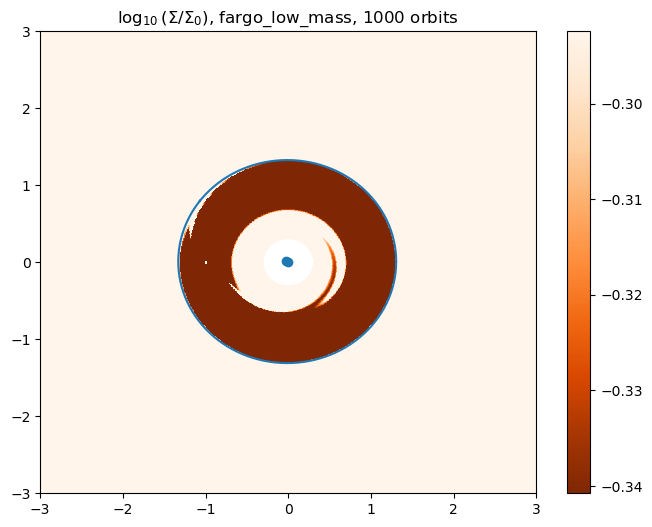

In [8]:
# index_for_mass=[2,0,1]
model_ind = 2

r_in = np.power(10,0.115)
r_out = np.power(10,0.125)
print(f"r_in: {r_in}\nr_out: {r_out}")

a = (r_in+r_out)/2
e = (r_out-r_in)/2
b = np.sqrt(a**2-e**2)

path = paths[model_ind]
print(f"Eccentricity for {path[43:-5]}: {e/a}")
print(f"e : {e}")

centerx = e
centery = 0
philist = np.linspace(0,2*np.pi,360)

x_ell_ = centerx + a*np.cos(philist)
y_ell_ = centery + b*np.sin(philist)

phi = 2.5
x_ell = x_ell_*np.cos(phi) - y_ell_*np.sin(phi)
y_ell = +x_ell_*np.sin(phi) + y_ell_*np.cos(phi)

plt.figure(figsize=(8,6))
plt.plot(x_ell,y_ell)
plt.scatter([0,2*e*np.cos(phi)],[0,2*e*np.sin(phi)], zorder=3)
plt.pcolormesh(X, Y,np.log10(rho_cube[model_ind][-1]/rho_cube[model_ind][0]),cmap=cm.Oranges_r,clim = (np.log10(0.51),np.log10(0.49)))
plt.xlim(-3,3)
plt.ylim(-3,3)
plt.title(f"$\\log_{{10}} \\left(\\Sigma / \\Sigma_0\\right)$, {path[43:-5]}, {(frame)*10} orbits")
plt.colorbar()

[0.01151242 0.06896789 0.14856041]


Text(0, 0.5, 'eccentricity')

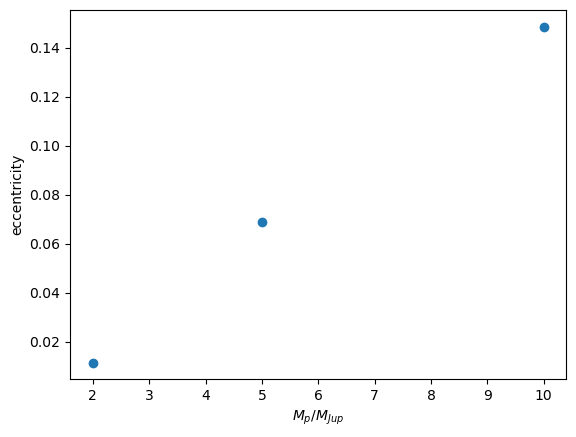

In [9]:
## make a plot for the eccentricities.
r_in_log = [0.115,0.14,0.17]
r_out_log = [0.125,0.20,0.30]

r_in = np.power(10,r_in_log)
r_out = np.power(10, r_out_log)

a = (r_in + r_out)/2
e = (r_out-r_in)/2
ecc = e/a
print(ecc)

plt.scatter([2,5,10],ecc)
plt.xlabel("$M_p/M_{Jup}$")
plt.ylabel("eccentricity")

[0.011512416822289855+/-0.008139788711646298
 0.06896788945366301+/-0.008102145062480231
 0.14856040730904885+/-0.007961197133778054]


Text(0, 0.5, 'eccentricity')

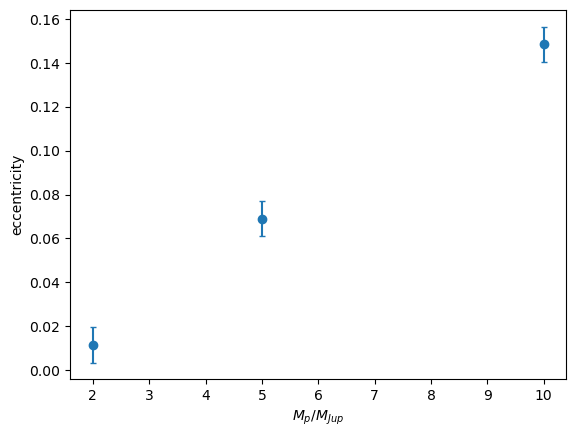

In [10]:
from uncertainties import ufloat

## make a plot for the eccentricities.
r_in_log = [ufloat(0.115,0.005),ufloat(0.14,0.005),ufloat(0.17,0.005)]
r_out_log = [ufloat(0.125,0.005),ufloat(0.20,0.005),ufloat(0.30,0.005)]

r_in = np.power(10,r_in_log)
r_out = np.power(10, r_out_log)

a = (r_in + r_out)/2
e = (r_out-r_in)/2
ecc = e/a
print(ecc)
ecc_values = [ee.nominal_value for ee in ecc]
ecc_errs = [ee.std_dev for ee in ecc]

plt.errorbar([2,5,10],ecc_values, yerr = ecc_errs, fmt="o", capsize=2)
plt.xlabel("$M_p/M_{Jup}$")
plt.ylabel("eccentricity")

# Again, but for viscosities

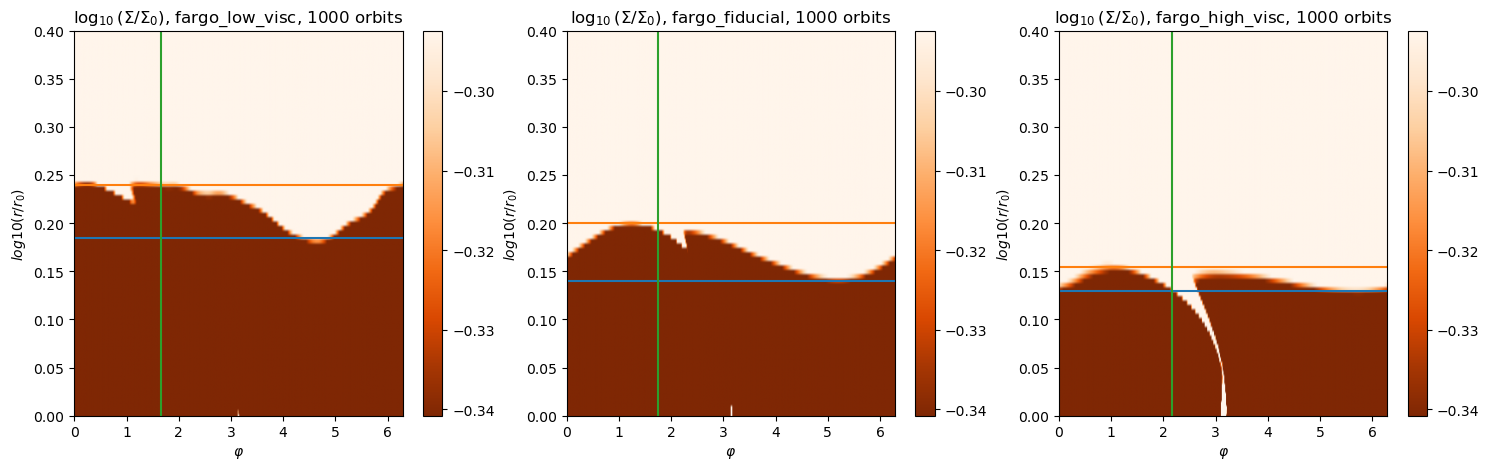

In [11]:
%matplotlib inline
r_min = 0.3
r_max = 7
index_for_visc=[4,0,3]

r_in_log = [0.185,0.14,0.13]
r_out_log = [0.24,0.20,0.155]
phi_ellipse = [4.8-np.pi,4.9-np.pi,5.3-np.pi]

plt.figure(figsize=(18,5))
frame = 100

for it,i in enumerate(index_for_visc):
    path = paths[i]
    
        
    plt.subplot(1,3,it+1)
    
    plt.imshow(np.log10(rho_cube[i][-1]/rho_cube[i][0]), origin='lower', cmap=cm.Oranges_r, aspect='auto',extent=[0,2*np.pi,np.log10(r_min), np.log10(r_max)],clim = (np.log10(0.51),np.log10(0.49)))
    plt.plot([0,np.pi*2],[r_in_log[it],r_in_log[it]])
    plt.plot([0,np.pi*2],[r_out_log[it],r_out_log[it]])
    plt.plot([phi_ellipse[it], phi_ellipse[it]],[-0.5,0.8])
    plt.title(f"$\\log_{{10}} \\left(\\Sigma / \\Sigma_0\\right)$, {path[43:-5]}, {(frame)*10} orbits")
    plt.ylim(0,0.4)
    plt.ylabel("$log10(r/r_0)$")
    plt.xlabel("$\\varphi$")
    plt.colorbar()


r_in: 1.5135612484362082
r_out: 1.7378008287493754
Eccentricity for fargo_low_visc: 0.06896788945366292


/scratch/3208986/ipykernel_3170439/1669706088.py:28: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  plt.pcolormesh(X, Y,np.log10(rho_cube[model_ind][-1]/rho_cube[model_ind][0]),cmap=cm.Oranges_r,clim = (np.log10(0.51),np.log10(0.49)))


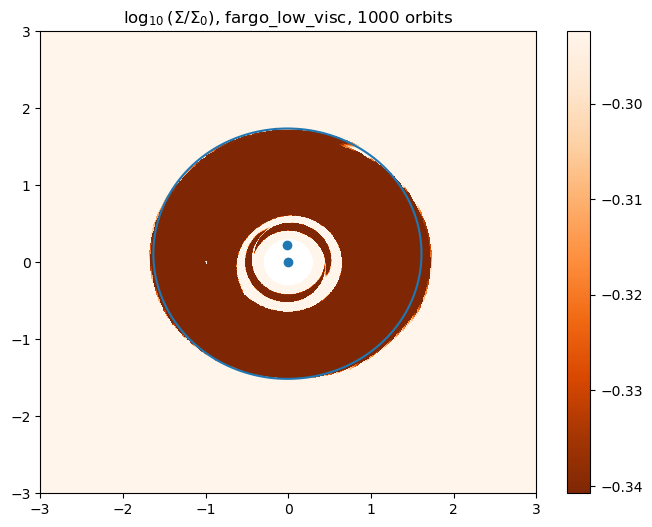

In [12]:
# index_for_mass=[2,0,1]
model_ind = index_for_visc[0]

r_in = np.power(10,0.18)
r_out = np.power(10,0.24)

a = (r_in+r_out)/2
e = (r_out-r_in)/2
b = np.sqrt(a**2-e**2)
print(f"r_in: {r_in}\nr_out: {r_out}")
path = paths[model_ind]
print(f"Eccentricity for {path[43:-5]}: {e/a}")

centerx = e
centery = 0
philist = np.linspace(0,2*np.pi,360)

x_ell_ = centerx + a*np.cos(philist)
y_ell_ = centery + b*np.sin(philist)

phi = 4.8- np.pi
x_ell = x_ell_*np.cos(phi) - y_ell_*np.sin(phi)
y_ell = +x_ell_*np.sin(phi) + y_ell_*np.cos(phi)

plt.figure(figsize=(8,6))
plt.plot(x_ell,y_ell)
plt.scatter([0,2*e*np.cos(phi)],[0,2*e*np.sin(phi)], zorder=3)
plt.pcolormesh(X, Y,np.log10(rho_cube[model_ind][-1]/rho_cube[model_ind][0]),cmap=cm.Oranges_r,clim = (np.log10(0.51),np.log10(0.49)))

plt.title(f"$\\log_{{10}} \\left(\\Sigma / \\Sigma_0\\right)$, {path[43:-5]}, {(frame)*10} orbits")
plt.xlim(-3,3)
plt.ylim(-3,3)
plt.colorbar()

#### I just can't make this look right. That's why I'll give it large uncertainties.

r_in: 1.3489628825916535
r_out: 1.428893958511103
Eccentricity for fargo_high_visc: 0.028774368331997358


/scratch/3208986/ipykernel_3170439/2551373818.py:28: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  plt.pcolormesh(X, Y,np.log10(rho_cube[model_ind][-1]/rho_cube[model_ind][0]),cmap=cm.Oranges_r,clim = (np.log10(0.51),np.log10(0.49)))


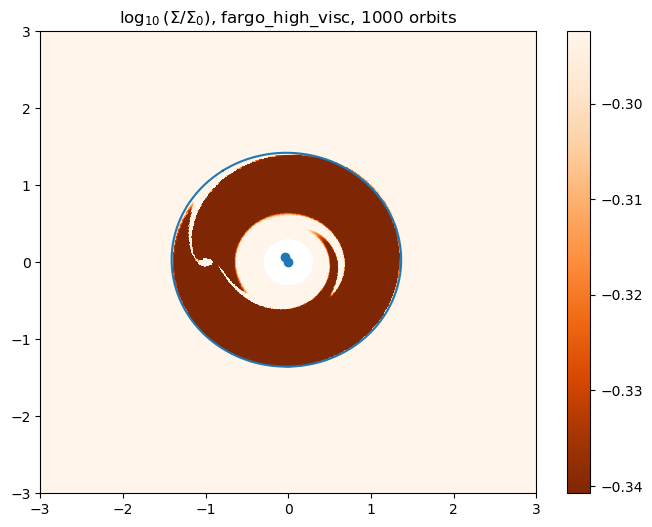

In [13]:
# index_for_mass=[2,0,1]
model_ind = index_for_visc[2]

r_in = np.power(10,0.13)
r_out = np.power(10,0.155)

a = (r_in+r_out)/2
e = (r_out-r_in)/2
b = np.sqrt(a**2-e**2)
print(f"r_in: {r_in}\nr_out: {r_out}")
path = paths[model_ind]
print(f"Eccentricity for {path[43:-5]}: {e/a}")

centerx = e
centery = 0
philist = np.linspace(0,2*np.pi,360)

x_ell_ = centerx + a*np.cos(philist)
y_ell_ = centery + b*np.sin(philist)

phi = 5.3- np.pi
x_ell = x_ell_*np.cos(phi) - y_ell_*np.sin(phi)
y_ell = +x_ell_*np.sin(phi) + y_ell_*np.cos(phi)

plt.figure(figsize=(8,6))
plt.plot(x_ell,y_ell)
plt.scatter([0,2*e*np.cos(phi)],[0,2*e*np.sin(phi)], zorder=3)
plt.pcolormesh(X, Y,np.log10(rho_cube[model_ind][-1]/rho_cube[model_ind][0]),cmap=cm.Oranges_r,clim = (np.log10(0.51),np.log10(0.49)))

plt.title(f"$\\log_{{10}} \\left(\\Sigma / \\Sigma_0\\right)$, {path[43:-5]}, {(frame)*10} orbits")
plt.xlim(-3,3)
plt.ylim(-3,3)
plt.colorbar()

[0.06323659565621458+/-0.016216626840525494
 0.06896788945366301+/-0.008102145062480231
 0.028774368331997358+/-0.008134127319996532]


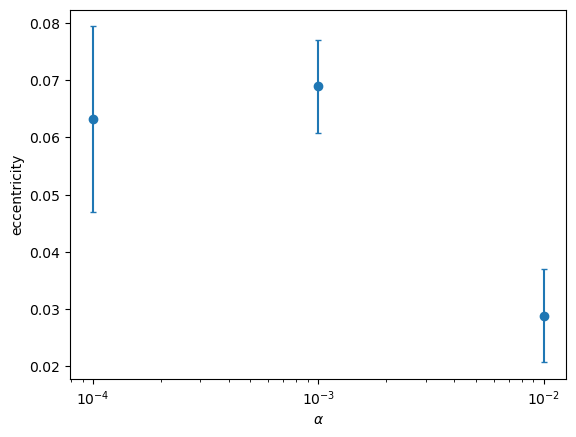

In [14]:

from uncertainties import ufloat
r_in_log = [ufloat(0.185,0.01),ufloat(0.14,0.005),ufloat(0.13,0.005)]
r_out_log = [ufloat(0.24,0.01),ufloat(0.20,0.005),ufloat(0.155,0.005)]



r_in = np.power(10,r_in_log)
r_out = np.power(10, r_out_log)

a = (r_in + r_out)/2
e = (r_out-r_in)/2
ecc = e/a
print(ecc)
ecc_values = [ee.nominal_value for ee in ecc]
ecc_errs = [ee.std_dev for ee in ecc]

plt.errorbar([1e-4,1e-3,1e-2],ecc_values, yerr = ecc_errs, fmt="o", capsize=2)
plt.xlabel("$\\alpha$")
plt.ylabel("eccentricity")
plt.xscale("log")

# And again, for different sigma slopes.

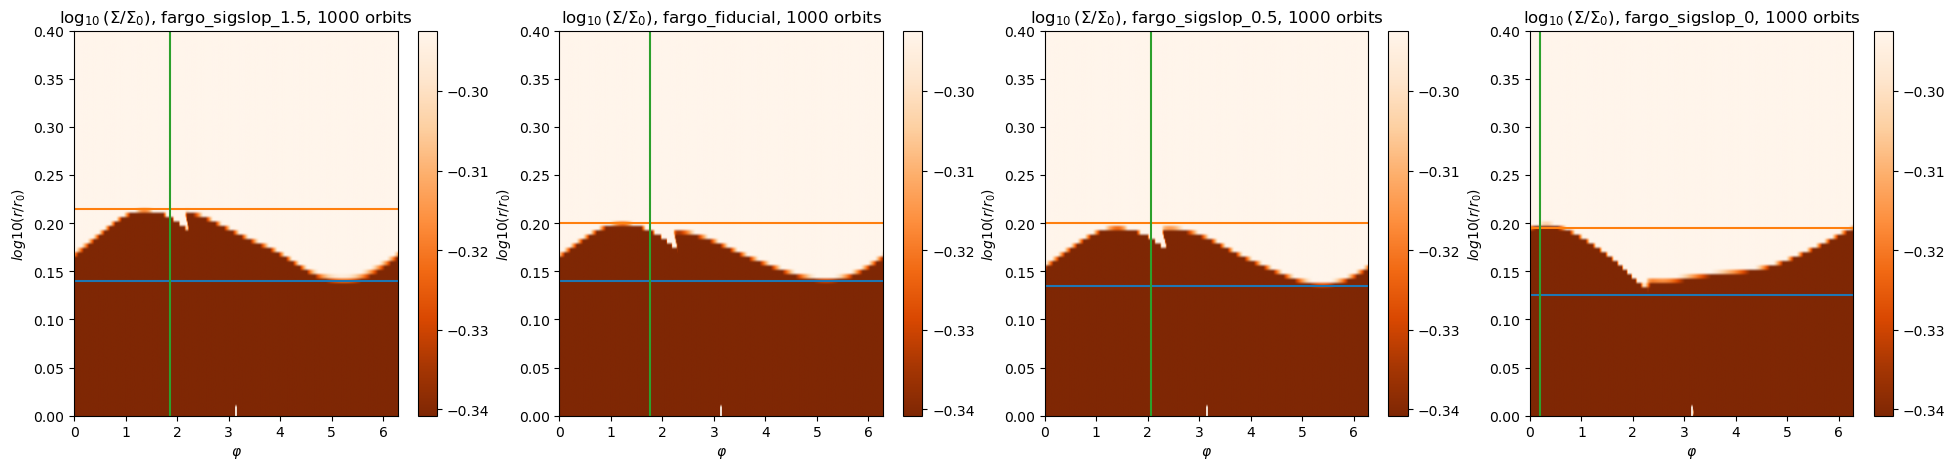

In [15]:
%matplotlib inline
r_min = 0.3
r_max = 7
index_for_sigslop = [8,0,6,5]

r_in_log = [0.14,0.14,0.135,0.125]
r_out_log = [0.215,0.20,0.20,0.195]
phi_ellipse = [5.0-np.pi,4.9-np.pi,5.2-np.pi,0.2]

plt.figure(figsize=(24,5))
frame = 100

for it,i in enumerate(index_for_sigslop):
    path = paths[i]
    
        
    plt.subplot(1,4,it+1)
    
    plt.imshow(np.log10(rho_cube[i][-1]/rho_cube[i][0]), origin='lower', cmap=cm.Oranges_r, aspect='auto',extent=[0,2*np.pi,np.log10(r_min), np.log10(r_max)],clim = (np.log10(0.51),np.log10(0.49)))
    plt.plot([0,np.pi*2],[r_in_log[it],r_in_log[it]])
    plt.plot([0,np.pi*2],[r_out_log[it],r_out_log[it]])
    plt.plot([phi_ellipse[it], phi_ellipse[it]],[-0.5,0.8])
    plt.title(f"$\\log_{{10}} \\left(\\Sigma / \\Sigma_0\\right)$, {path[43:-5]}, {(frame)*10} orbits")
    plt.ylim(0,0.4)
    plt.ylabel("$log10(r/r_0)$")
    plt.xlabel("$\\varphi$")
    plt.colorbar()


0.14 0.215
r_in: 1.3803842646028848
r_out: 1.6405897731995394
Eccentricity for fargo_sigslop_1.5: 0.08613298404442375


/scratch/3208986/ipykernel_3170439/1228896684.py:27: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  plt.pcolormesh(X, Y,np.log10(rho_cube[model_ind][-1]/rho_cube[model_ind][0]),cmap=cm.Oranges_r,clim = (np.log10(0.51),np.log10(0.49)))


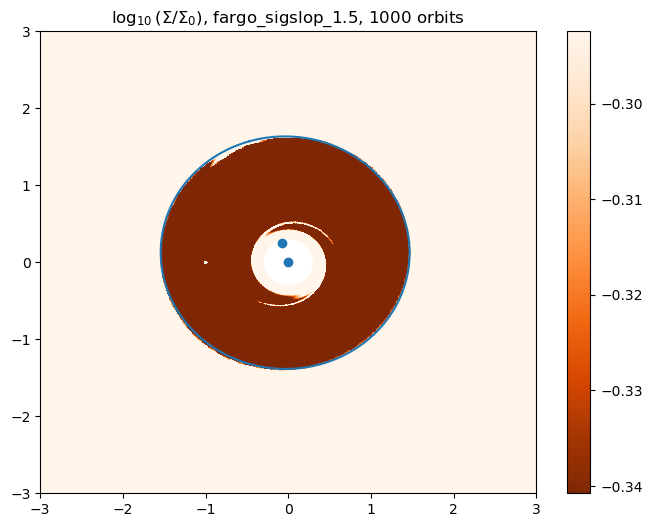

In [16]:
model_ind = index_for_sigslop[0]
print(r_in_log[0],r_out_log[0])
r_in = np.power(10,0.14)
r_out = np.power(10,0.215)

a = (r_in+r_out)/2
e = (r_out-r_in)/2
b = np.sqrt(a**2-e**2)
print(f"r_in: {r_in}\nr_out: {r_out}")
path = paths[model_ind]
print(f"Eccentricity for {path[43:-5]}: {e/a}")

centerx = e
centery = 0
philist = np.linspace(0,2*np.pi,360)

x_ell_ = centerx + a*np.cos(philist)
y_ell_ = centery + b*np.sin(philist)

phi = 5.0- np.pi
x_ell = x_ell_*np.cos(phi) - y_ell_*np.sin(phi)
y_ell = +x_ell_*np.sin(phi) + y_ell_*np.cos(phi)

plt.figure(figsize=(8,6))
plt.plot(x_ell,y_ell)
plt.scatter([0,2*e*np.cos(phi)],[0,2*e*np.sin(phi)], zorder=3)
plt.pcolormesh(X, Y,np.log10(rho_cube[model_ind][-1]/rho_cube[model_ind][0]),cmap=cm.Oranges_r,clim = (np.log10(0.51),np.log10(0.49)))

plt.title(f"$\\log_{{10}} \\left(\\Sigma / \\Sigma_0\\right)$, {path[43:-5]}, {(frame)*10} orbits")
plt.xlim(-3,3)
plt.ylim(-3,3)
plt.colorbar()



0.135 0.2
r_in: 1.3645831365889245
r_out: 1.5848931924611136
Eccentricity for fargo_sigslop_0.5: 0.07469463433298552


/scratch/3208986/ipykernel_3170439/742589891.py:28: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  plt.pcolormesh(X, Y,np.log10(rho_cube[model_ind][-1]/rho_cube[model_ind][0]),cmap=cm.Oranges_r,clim = (np.log10(0.51),np.log10(0.49)))


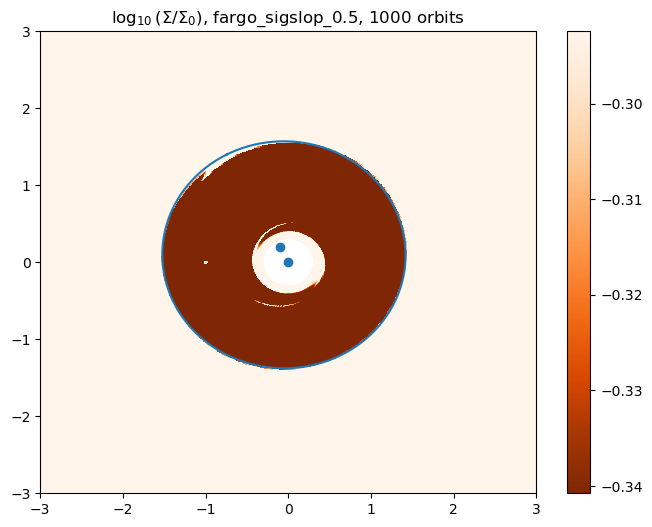

In [17]:
# index_for_mass=[2,0,1]
model_ind = index_for_sigslop[2]
print(r_in_log[2],r_out_log[2])
r_in = np.power(10,0.135)
r_out = np.power(10,0.2)

a = (r_in+r_out)/2
e = (r_out-r_in)/2
b = np.sqrt(a**2-e**2)
print(f"r_in: {r_in}\nr_out: {r_out}")
path = paths[model_ind]
print(f"Eccentricity for {path[43:-5]}: {e/a}")

centerx = e
centery = 0
philist = np.linspace(0,2*np.pi,360)

x_ell_ = centerx + a*np.cos(philist)
y_ell_ = centery + b*np.sin(philist)

phi = 5.2- np.pi
x_ell = x_ell_*np.cos(phi) - y_ell_*np.sin(phi)
y_ell = +x_ell_*np.sin(phi) + y_ell_*np.cos(phi)

plt.figure(figsize=(8,6))
plt.plot(x_ell,y_ell)
plt.scatter([0,2*e*np.cos(phi)],[0,2*e*np.sin(phi)], zorder=3)
plt.pcolormesh(X, Y,np.log10(rho_cube[model_ind][-1]/rho_cube[model_ind][0]),cmap=cm.Oranges_r,clim = (np.log10(0.51),np.log10(0.49)))

plt.title(f"$\\log_{{10}} \\left(\\Sigma / \\Sigma_0\\right)$, {path[43:-5]}, {(frame)*10} orbits")
plt.xlim(-3,3)
plt.ylim(-3,3)
plt.colorbar()



0.125 0.195
r_in: 1.333521432163324
r_out: 1.566751070108149
Eccentricity for fargo_sigslop_0: 0.08041645664749132


/scratch/3208986/ipykernel_3170439/3972050390.py:28: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  plt.pcolormesh(X, Y,np.log10(rho_cube[model_ind][-1]/rho_cube[model_ind][0]),cmap=cm.Oranges_r,clim = (np.log10(0.51),np.log10(0.49)))


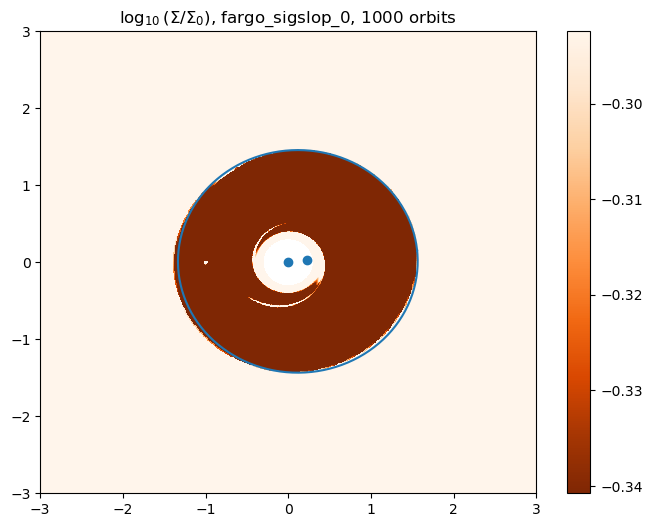

In [18]:
# index_for_mass=[2,0,1]
model_ind = index_for_sigslop[3]
print(r_in_log[3],r_out_log[3])
r_in = np.power(10,0.125)
r_out = np.power(10,0.195)

a = (r_in+r_out)/2
e = (r_out-r_in)/2
b = np.sqrt(a**2-e**2)
print(f"r_in: {r_in}\nr_out: {r_out}")
path = paths[model_ind]
print(f"Eccentricity for {path[43:-5]}: {e/a}")

centerx = e
centery = 0
philist = np.linspace(0,2*np.pi,360)

x_ell_ = centerx + a*np.cos(philist)
y_ell_ = centery + b*np.sin(philist)

phi = 0.1
x_ell = x_ell_*np.cos(phi) - y_ell_*np.sin(phi)
y_ell = +x_ell_*np.sin(phi) + y_ell_*np.cos(phi)

plt.figure(figsize=(8,6))
plt.plot(x_ell,y_ell)
plt.scatter([0,2*e*np.cos(phi)],[0,2*e*np.sin(phi)], zorder=3)
plt.pcolormesh(X, Y,np.log10(rho_cube[model_ind][-1]/rho_cube[model_ind][0]),cmap=cm.Oranges_r,clim = (np.log10(0.51),np.log10(0.49)))

plt.title(f"$\\log_{{10}} \\left(\\Sigma / \\Sigma_0\\right)$, {path[43:-5]}, {(frame)*10} orbits")
plt.xlim(-3,3)
plt.ylim(-3,3)
plt.colorbar()

#### I just can't make this look right. That's why I'll give it large uncertainties.

[0.08613298404442375+/-0.008080471458189787
 0.06896788945366301+/-0.008102145062480231
 0.07469463433298552+/-0.008095447419047249
 0.08041645664749132+/-0.016176444503259103]


Text(0, 0.5, 'eccentricity')

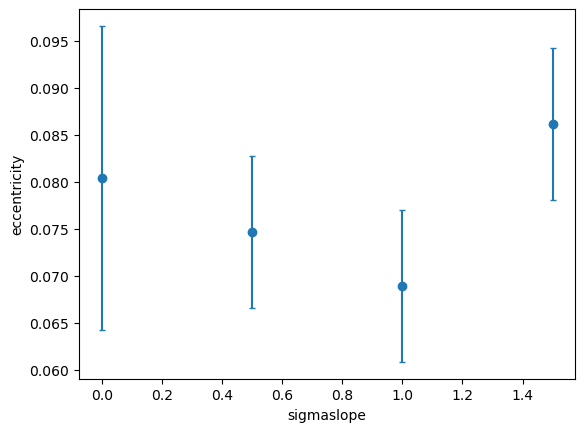

In [19]:
from uncertainties import ufloat


r_in_log = [ufloat(0.14,0.005),ufloat(0.14,0.005),ufloat(0.135,0.005),ufloat(0.125,0.01)]
r_out_log = [ufloat(0.215,0.005),ufloat(0.20,0.005),ufloat(0.20,0.005),ufloat(0.195,0.01)]

r_in = np.power(10,r_in_log)
r_out = np.power(10, r_out_log)

a = (r_in + r_out)/2
e = (r_out-r_in)/2
ecc = e/a
print(ecc)
ecc_values = [ee.nominal_value for ee in ecc]
ecc_errs = [ee.std_dev for ee in ecc]

plt.errorbar([1.5,1.0,0.5,0],ecc_values, yerr = ecc_errs, fmt="o", capsize=2)
plt.xlabel("sigmaslope")
plt.ylabel("eccentricity")
#plt.xscale("log")

# Summary

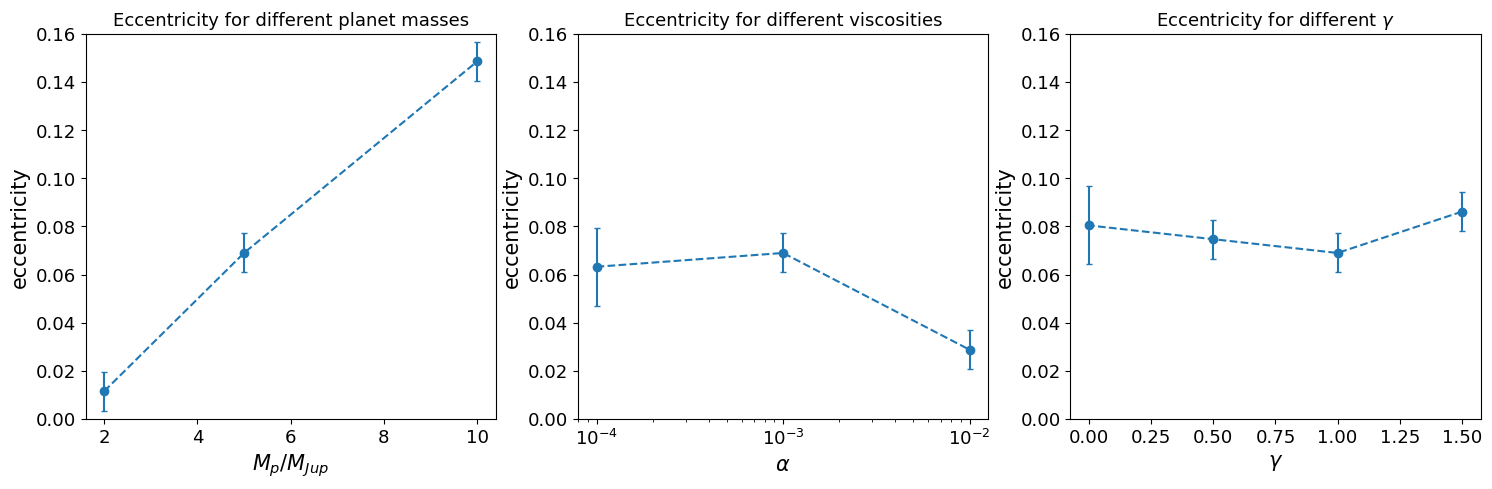

In [23]:
from uncertainties import ufloat

## make a plot for the eccentricities.
r_in_log = [ufloat(0.115,0.005),ufloat(0.14,0.005),ufloat(0.17,0.005)]
r_out_log = [ufloat(0.125,0.005),ufloat(0.20,0.005),ufloat(0.30,0.005)]

r_in = np.power(10,r_in_log)
r_out = np.power(10, r_out_log)

a = (r_in + r_out)/2
e = (r_out-r_in)/2
ecc = e/a
ecc_values = [ee.nominal_value for ee in ecc]
ecc_errs = [ee.std_dev for ee in ecc]

plt.figure(figsize=(18,5))
plt.subplot(1,3,1)
plt.errorbar([2,5,10],ecc_values, yerr = ecc_errs, fmt="o--", capsize=2)
plt.xlabel("$M_p/M_{Jup}$")
plt.ylabel("eccentricity")
plt.ylim(0,0.16)
plt.title("Eccentricity for different planet masses")


plt.subplot(1,3,2)
r_in_log = [ufloat(0.185,0.01),ufloat(0.14,0.005),ufloat(0.13,0.005)]
r_out_log = [ufloat(0.24,0.01),ufloat(0.20,0.005),ufloat(0.155,0.005)]



r_in = np.power(10,r_in_log)
r_out = np.power(10, r_out_log)

a = (r_in + r_out)/2
e = (r_out-r_in)/2
ecc = e/a
ecc_values = [ee.nominal_value for ee in ecc]
ecc_errs = [ee.std_dev for ee in ecc]

plt.errorbar([1e-4,1e-3,1e-2],ecc_values, yerr = ecc_errs, fmt="o--", capsize=2)
plt.xlabel("$\\alpha$")
plt.ylabel("eccentricity")
plt.xscale("log")
plt.ylim(0,0.16)
plt.title("Eccentricity for different viscosities")

plt.subplot(1,3,3)
r_in_log = [ufloat(0.14,0.005),ufloat(0.14,0.005),ufloat(0.135,0.005),ufloat(0.125,0.01)]
r_out_log = [ufloat(0.215,0.005),ufloat(0.20,0.005),ufloat(0.20,0.005),ufloat(0.195,0.01)]

r_in = np.power(10,r_in_log)
r_out = np.power(10, r_out_log)

a = (r_in + r_out)/2
e = (r_out-r_in)/2
ecc = e/a
ecc_values = [ee.nominal_value for ee in ecc]
ecc_errs = [ee.std_dev for ee in ecc]

plt.errorbar([1.5,1.0,0.5,0],ecc_values, yerr = ecc_errs, fmt="o--", capsize=2)
plt.xlabel("$\\gamma$")
plt.ylabel("eccentricity")
plt.ylim(0,0.16)
plt.title("Eccentricity for different $\\gamma$")

plt.savefig("img/Eccentricities.PNG", bbox_inches="tight")

In [65]:
rin = 39.5
rout= 98.5
print((rout-rin)/(rout+rin))

0.427536231884058


# A plot to explain what I did

r_in: 1.3489628825916535
r_out: 1.62181009735893
Eccentricity for fargo_fiducial: 0.09184384556096746
r_in: 1.3803842646028848
r_out: 1.5848931924611136
Eccentricity for fargo_fiducial: 0.06896788945366301


/scratch/3208986/ipykernel_3170439/4234581796.py:66: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  plt.pcolormesh(X, Y,np.log10(rho_cube[index][-1]/rho_cube[index][0]),cmap=cm.Oranges_r,clim = (np.log10(0.51),np.log10(0.49)))
/scratch/3208986/ipykernel_3170439/4234581796.py:101: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  plt.pcolormesh(X, Y,np.log10(rho_cube[index][-1]/rho_cube[index][0]),cmap=cm.Oranges_r,clim = (np.log10(0.51),np.log10(0.49)))


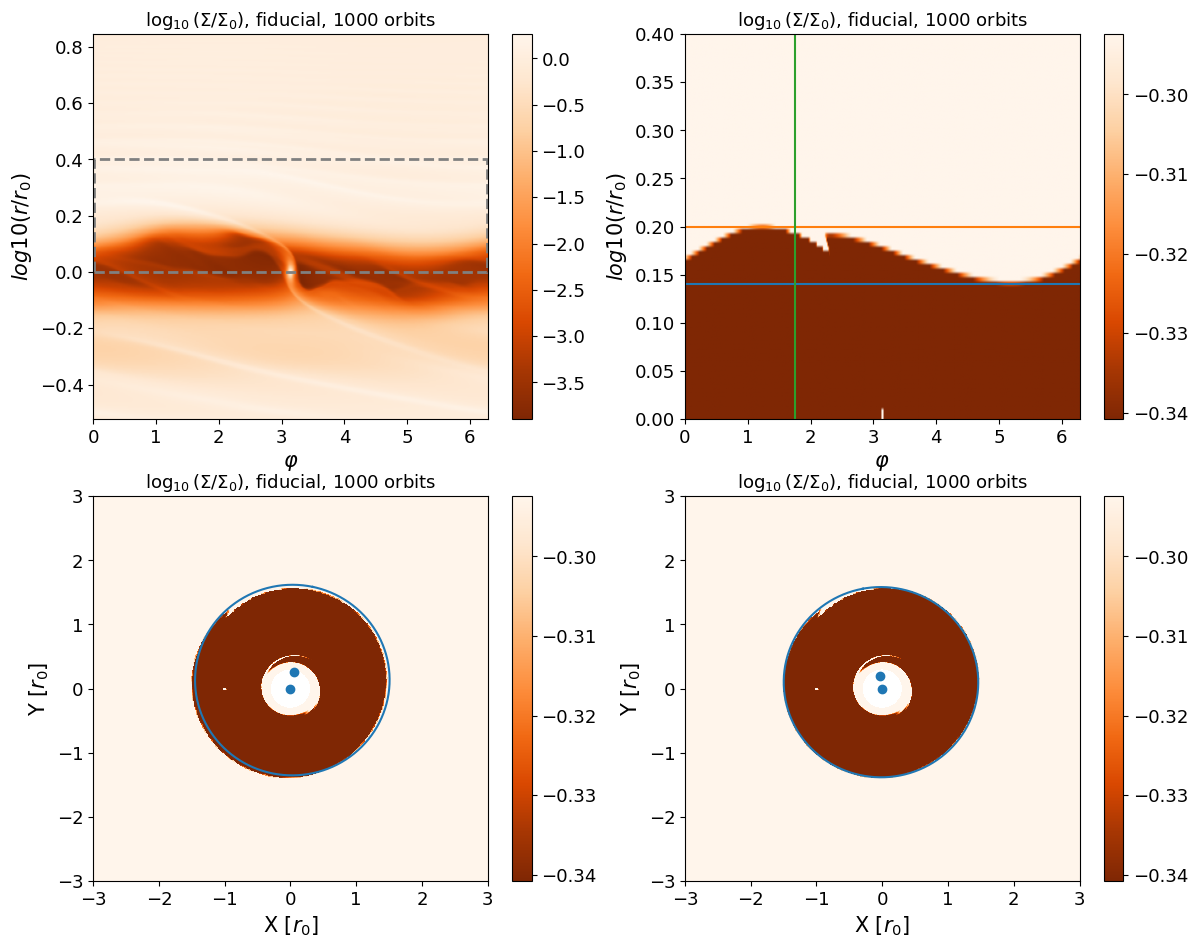

In [25]:
%matplotlib inline
r_min = 0.3
r_max = 7
index = 0

r_in_log = [0.14,0.17,0.115,]
r_out_log = [0.20,0.30,0.125,]
phi_ellipse = [4.9-np.pi,3.0,2.5,]

plt.figure(figsize=(14,11))
frame = 100

path = paths[index]

plt.subplot(2,2,1)

plt.imshow(np.log10(rho_cube[index][-1]/rho_cube[index][0]), origin='lower', cmap=cm.Oranges_r, aspect='auto',extent=[0,2*np.pi,np.log10(r_min), np.log10(r_max)])#,clim = (np.log10(0.51),np.log10(0.49)))
#plt.plot([0,np.pi*2],[r_in_log[index],r_in_log[index]])
#plt.plot([0,np.pi*2],[r_out_log[index],r_out_log[index]])
#plt.plot([phi_ellipse[index], phi_ellipse[index]],[-0.5,0.8])
plt.plot([0.02,2*np.pi-0.01,2*np.pi-0.01,0.02, 0.02],[0,0,0.4,0.4,0], color="grey", linestyle="--", linewidth = 2)

plt.title(f"$\\log_{{10}} \\left(\\Sigma / \\Sigma_0\\right)$, fiducial, {(frame)*10} orbits")
#plt.ylim(0,0.4)
plt.ylabel("$log10(r/r_0)$")
plt.xlabel("$\\varphi$")
plt.colorbar()

plt.subplot(2,2,2)

plt.imshow(np.log10(rho_cube[index][-1]/rho_cube[index][0]), origin='lower', cmap=cm.Oranges_r, aspect='auto',extent=[0,2*np.pi,np.log10(r_min), np.log10(r_max)],clim = (np.log10(0.51),np.log10(0.49)))
plt.plot([0,np.pi*2],[r_in_log[index],r_in_log[index]])
plt.plot([0,np.pi*2],[r_out_log[index],r_out_log[index]])
plt.plot([phi_ellipse[index], phi_ellipse[index]],[-0.5,0.8])
plt.title(f"$\\log_{{10}} \\left(\\Sigma / \\Sigma_0\\right)$, fiducial, {(frame)*10} orbits")
plt.ylim(0,0.4)
plt.ylabel("$log10(r/r_0)$")
plt.xlabel("$\\varphi$")
plt.colorbar()

plt.subplot(2,2,3)
r_in = np.power(10,r_in_log[index]-0.01)
r_out = np.power(10,r_out_log[index]+0.01)

a = (r_in+r_out)/2
e = (r_out-r_in)/2
b = np.sqrt(a**2-e**2)
print(f"r_in: {r_in}\nr_out: {r_out}")

print(f"Eccentricity for {path[43:-5]}: {e/a}")

centerx = e
centery = 0
philist = np.linspace(0,2*np.pi,360)

x_ell_ = centerx + a*np.cos(philist)
y_ell_ = centery + b*np.sin(philist)

phi = phi_ellipse[index]-0.4
x_ell = x_ell_*np.cos(phi) - y_ell_*np.sin(phi)
y_ell = +x_ell_*np.sin(phi) + y_ell_*np.cos(phi)

#plt.figure(figsize=(8,6))
plt.plot(x_ell,y_ell)
plt.scatter([0,2*e*np.cos(phi)],[0,2*e*np.sin(phi)], zorder=3)
plt.pcolormesh(X, Y,np.log10(rho_cube[index][-1]/rho_cube[index][0]),cmap=cm.Oranges_r,clim = (np.log10(0.51),np.log10(0.49)))

plt.title(f"$\\log_{{10}} \\left(\\Sigma / \\Sigma_0\\right)$, fiducial, {(frame)*10} orbits")
plt.xlim(-3,3)
plt.ylim(-3,3)
plt.xlabel("X [$r_0$]")
plt.ylabel("Y [$r_0$]")
plt.colorbar()

plt.subplot(2,2,4)

r_in = np.power(10,r_in_log[index])
r_out = np.power(10,r_out_log[index])

a = (r_in+r_out)/2
e = (r_out-r_in)/2
b = np.sqrt(a**2-e**2)
print(f"r_in: {r_in}\nr_out: {r_out}")

print(f"Eccentricity for {path[43:-5]}: {e/a}")

centerx = e
centery = 0
philist = np.linspace(0,2*np.pi,360)

x_ell_ = centerx + a*np.cos(philist)
y_ell_ = centery + b*np.sin(philist)

phi = phi_ellipse[index]
x_ell = x_ell_*np.cos(phi) - y_ell_*np.sin(phi)
y_ell = +x_ell_*np.sin(phi) + y_ell_*np.cos(phi)

#plt.figure(figsize=(8,6))
plt.plot(x_ell,y_ell)
plt.scatter([0,2*e*np.cos(phi)],[0,2*e*np.sin(phi)], zorder=3)
plt.pcolormesh(X, Y,np.log10(rho_cube[index][-1]/rho_cube[index][0]),cmap=cm.Oranges_r,clim = (np.log10(0.51),np.log10(0.49)))

plt.title(f"$\\log_{{10}} \\left(\\Sigma / \\Sigma_0\\right)$, fiducial, {(frame)*10} orbits")
plt.xlim(-3,3)
plt.ylim(-3,3)
plt.xlabel("X [$r_0$]")
plt.ylabel("Y [$r_0$]")
plt.colorbar()


plt.savefig("img/ecc_tutorial.PNG")

In [100]:
np.log10(0.5)

np.float64(-0.3010299956639812)

(np.float64(-0.5), np.float64(752.5), np.float64(687.5), np.float64(-0.5))

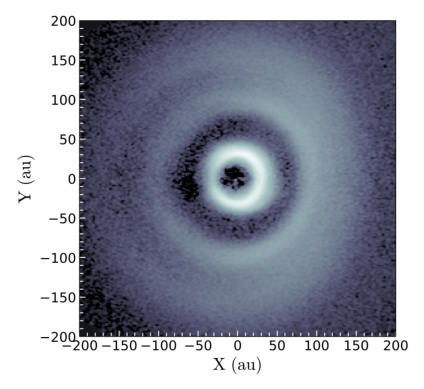

In [2]:
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

img = np.asarray(Image.open('capelleveen_deprojected.png'))

plt.imshow(img)
plt.axis('off')


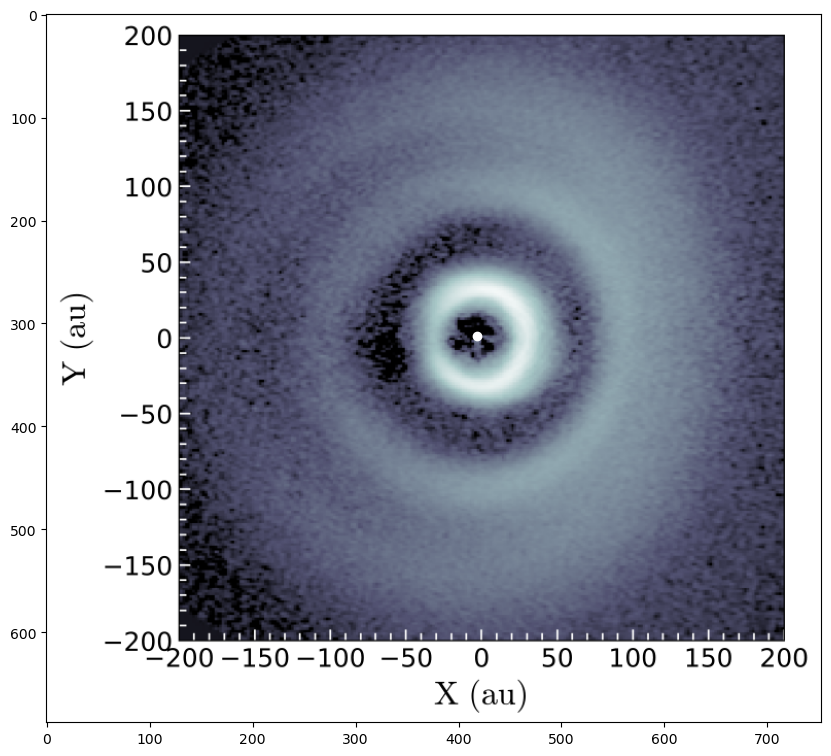

In [3]:
centerx = 418
centery = 312

r_in = 200
r_out=300

plt.figure(figsize=(10,10))
plt.imshow(img)
plt.scatter(centerx,centery, color="white")
#plt.axis('off')




r_in: 115
r_out: 130
Eccentricity: 0.061224489795918366


<Figure size 640x480 with 0 Axes>

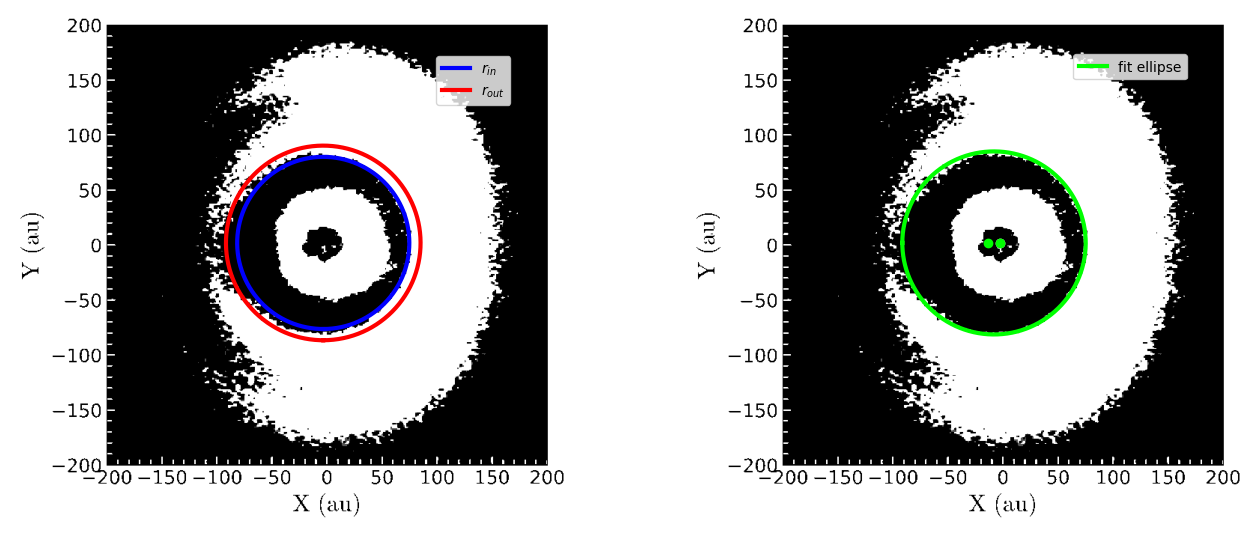

In [10]:
centerx = 418
centery = 312

r_in = 115
r_out=130
img_float = np.array(img, dtype='<f4')

mean_img = (img_float[:,:,0]+img_float[:,:,1]+img_float[:,:,2])/3

plt.tight_layout()
plt.figure(figsize=(16,8))
plt.subplot(1,2,1)
plt.imshow(mean_img, cmap="gray", clim=(110,111))#, clim=(80,160))
#plt.colorbar()
#plt.scatter(centerx,centery, color="white", )
plt.axis('off')


a = (r_in+r_out)/2
e = (r_out-r_in)/2
b = np.sqrt(a**2-e**2)
print(f"r_in: {r_in}\nr_out: {r_out}")

print(f"Eccentricity: {e/a}")

centerx_ell = e
centery_ell = 0
philist = np.linspace(0,2*np.pi,360)

x_ell_ = centerx_ell + a*np.cos(philist)
y_ell_ = centery_ell + b*np.sin(philist)

phi = np.pi
x_ell = x_ell_*np.cos(phi) - y_ell_*np.sin(phi) + centerx
y_ell = +x_ell_*np.sin(phi) + y_ell_*np.cos(phi) + centery

#plt.figure(figsize=(8,6))

plt.plot(centerx+r_in*np.sin(philist),centery+r_in*np.cos(philist), color="blue", linewidth = 3, label="$r_{in}$" )
plt.plot(centerx+r_out*np.sin(philist),centery+r_out*np.cos(philist), color="red",linewidth = 3, label="$r_{out}$")
plt.legend(loc="lower right", bbox_to_anchor=(0.9,0.8))
plt.subplot(1,2,2)
plt.imshow(mean_img, cmap="gray", clim=(110,111))#, clim=(80,160))
#plt.colorbar()
plt.scatter(centerx,centery, color="white", )
plt.axis('off')
plt.plot(x_ell,y_ell,color="lime", linewidth = 3, label="fit ellipse")
plt.scatter([centerx,centerx+2*e*np.cos(phi)],[centery,centery+2*e*np.sin(phi)], zorder=3,color="lime")
plt.legend(loc="lower right", bbox_to_anchor=(0.9,0.85))
plt.savefig("img/garbage_ecc_estimate.PNG")

I don't think this is very trustworthy because
- we don't know what each channel even stands for
- Because of forward/backward scattering etc etc. one side is darker and the gap will hence appear more eccentric
- We have no idea what surface densities correspond to the pixel values.
- This might give us a (trashy) upper limit on the eccentricity at best.

In [30]:
img.dtype

dtype('uint8')

# 